# Suitability Analysis

Characterize the development potential and socioeconomic profile within 1–2 miles of Diridon Station to support transit-oriented development planning and opportunity analysis.

In [96]:
# --------------------------
# LIBRARIES
# --------------------------
# file path
import os
from pathlib import Path

# data management
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
from shapely.geometry import Point

# modeling
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier 

# evaluation
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, classification_report
)

# visualizing
import matplotlib.pyplot as plt

# settings
pd.set_option('display.max_columns', None)  # Show all columns when printing the DataFrame


In [2]:
# -----------------------------------------------------
# Step 1: Load Data
# -----------------------------------------------------
PROCESSED_DIR = Path("../data/processed")
PARCELS_FOR_ML = PROCESSED_DIR / "parcels_for_ml.parquet"
OUTPUT_DIR = Path("../output/suitability_model/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

parcels_model = gpd.read_parquet(PARCELS_FOR_ML)
parcels_model.head()



,OBJECTID_left,PARCELID,INTID_left,APN,LOTNUM,PARCELTYPE,FEATURECLA,PLANCRT,PLANMOD,LASTUPDATE_left,NOTES_left,COVERED,SHAPE_Leng_left,SHAPE_Area_left,CREATIONDA,geometry,OBJECTID_right,FACILITYID,INTID_right,ZONING,ZONINGABBR,REZONINGFI,PDUSE,PDDENSITY,DEVELOPEDA,APPROVALDA,COLORCODE,LASTUPDATE_right,NOTES_right,SHAPE_Leng_right,SHAPE_Area_right,overlap_area,zoning,zoning_class,zoning_planned,GEOID,public_transit_pct,walked_pct,drove_pct,pct_renters,vacancy_rate,median_rent,median_income,pct_white,pct_black,pct_asian,pct_latino,pct_college_plus,in_taz,urban_zone_flag,dist_to_station_miles,parcel_area
0,4378,1000,1000,09759046,46,Tax,Parcel,T-8284,None,2005-10-25,None,None,149.517344,1163.273287,1900-01-01,"POLYGON ((-121.92153 37.40344, -121.92148 37.4...",1396.0,1396,1396.0,A(PD),A(PD),88034,Res,25.6,Yes,None,17,2022-04-22,None,5039.839521,1.155021e+06,1163.273287,Other,Special Purpose,True,06085505006,3.273626,4.657196,60.370599,87.253849,7.577763,3210.0,205610.0,20.237282,0.887675,76.237624,4.933424,89.557753,0,0,6.621561,1.099912e-08
1,173262,1000000031,1000000031,30326084,6,Tax,Parcel,TR9494,None,2006-01-12,None,None,188.703136,2037.538177,1900-01-01,"POLYGON ((-121.96725 37.32211, -121.96704 37.3...",288.0,288,288.0,A(PD),A(PD),02028,Res,13,Yes,None,17,2022-04-22,None,737.405158,2.014218e+04,2037.538177,Other,Special Purpose,True,06085506301,2.352193,5.181182,68.817546,70.102136,10.362047,2461.0,121667.0,44.893158,4.763772,29.876495,19.407959,46.546175,1,0,4.607317,1.924470e-08
2,69247,1000000032,1000000032,30326083,5,Tax,Parcel,TR9494,None,2006-01-12,None,None,187.780061,2020.818784,1900-01-01,"POLYGON ((-121.96725 37.32202, -121.96704 37.3...",288.0,288,288.0,A(PD),A(PD),02028,Res,13,Yes,None,17,2022-04-22,None,737.405158,2.014218e+04,2020.818784,Other,Special Purpose,True,06085506301,2.352193,5.181182,68.817546,70.102136,10.362047,2461.0,121667.0,44.893158,4.763772,29.876495,19.407959,46.546175,1,0,4.608391,1.908676e-08
3,147109,1000000033,1000000033,30326082,4,Tax,Parcel,TR9494,None,2006-01-12,None,None,187.209294,1994.378436,1900-01-01,"POLYGON ((-121.96691 37.32205, -121.96689 37.3...",288.0,288,288.0,A(PD),A(PD),02028,Res,13,Yes,None,17,2022-04-22,None,737.405158,2.014218e+04,1994.378436,Other,Special Purpose,True,06085506301,2.352193,5.181182,68.817546,70.102136,10.362047,2461.0,121667.0,44.893158,4.763772,29.876495,19.407959,46.546175,1,0,4.590963,1.883703e-08
4,147110,1000000034,1000000034,30326081,3,Tax,Parcel,TR9494,None,2006-01-12,None,None,212.838294,2261.152730,1900-01-01,"POLYGON ((-121.9666 37.32198, -121.9666 37.321...",288.0,288,288.0,A(PD),A(PD),02028,Res,13,Yes,None,17,2022-04-22,None,737.405158,2.014218e+04,2261.152730,Other,Special Purpose,True,06085506301,2.352193,5.181182,68.817546,70.102136,10.362047,2461.0,121667.0,44.893158,4.763772,29.876495,19.407959,46.546175,1,0,4.578673,2.135674e-08


In [3]:
# =============================================================
# Step 2: Separate into features and labels 
# =============================================================

feature_cols = [
    'dist_to_station_miles',
    'parcel_area',
    'in_taz',
    'public_transit_pct', 
    'walked_pct', 
    'drove_pct', 
    'pct_renters',
    'vacancy_rate',
    'median_income',
    'median_rent',
    'pct_white',
    'pct_black',
    'pct_asian',
    'pct_latino',
    'pct_college_plus'
] 

feature_cols

X = parcels_model[feature_cols]
y = parcels_model["urban_zone_flag"]

In [18]:
# =============================================================
# Step 3: Train/Test Split
# =============================================================

X = parcels_model[feature_cols]
y = parcels_model["urban_zone_flag"]

# create test-train split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size = .80, 
    test_size=0.20,
    random_state=42,
    stratify=y
)

# training and validation split 
X_train, X_validate, y_train, y_validate = train_test_split(X_train, 
                                                            y_train, 
                                                            train_size = .75, 
                                                            test_size = .25, 
                                                            stratify = y_train)

# Scale continuous variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validate_scaled = scaler.transform(X_validate)
X_test_scaled = scaler.transform(X_test)




In [88]:
# =============================================================
# Step 4: Train ML Models
# =============================================================

# Logistic Regression
# --------------------
print("Training Logistic Regression...")
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model = lr.fit(X_train_scaled, y_train)

# predict on the validation data
lr_pred = lr_model.predict(X_validate_scaled)

# Random Forest
# --------------------
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=350,
    max_depth=18,
    min_samples_leaf=8,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)
rf_model = rf.fit(X_train_scaled, y_train)

# predict on the validation data
rf_pred = rf_model.predict(X_validate_scaled)


# XG Boost
# --------------------
print("Training XGBoost...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
xgb_model = xgb.fit(X_train_scaled, y_train)

# predict on the validation data
xgb_pred = xgb_model.predict(X_validate_scaled)

# AdaBoost
# --------------------
print("Training AdaBoost...")

# Create a base estimator with balanced class weights
base_estimator = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',
    random_state=42
)
ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
ada_model = ada.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# predict on the validation data
ada_pred = ada_model.predict(X_validate_scaled)


# Ensemble
# --------------------
print("Training Voting Ensemble...")
ensemble = VotingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("xgb", xgb), ("ada", ada)],
    voting="soft",
    weights=[1, 1, 1, 1]  # XGBoost gets more weight
)
ensemble_model = ensemble.fit(X_train_scaled, y_train)

# predict on the validation data
ensemble_pred = ensemble_model.predict(X_validate_scaled)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training AdaBoost...
Training Voting Ensemble...


In [89]:

# =============================================================
# Step 5: Evaluate Models
# =============================================================

def evaluate(model, X_test, y_test, name):
    print(f"\n---- {name} PERFORMANCE ----")
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, probs)
    print("ROC AUC:", round(auc, 3))
    print(classification_report(y_test, preds))

evaluate(lr, X_test_scaled, y_test, "Logit")
evaluate(rf, X_test_scaled, y_test, "Random Forest")
evaluate(xgb, X_test_scaled, y_test, "XGBoost")
evaluate(ada, X_test_scaled, y_test, "AdaBoost")
evaluate(ensemble, X_test_scaled, y_test, "Ensemble")



---- Logit PERFORMANCE ----
ROC AUC: 0.87
              precision    recall  f1-score   support

           0       1.00      0.77      0.87     38315
           1       0.07      0.83      0.13       800

    accuracy                           0.77     39115
   macro avg       0.53      0.80      0.50     39115
weighted avg       0.98      0.77      0.85     39115


---- Random Forest PERFORMANCE ----
ROC AUC: 0.985
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     38315
           1       0.37      0.87      0.52       800

    accuracy                           0.97     39115
   macro avg       0.68      0.92      0.75     39115
weighted avg       0.98      0.97      0.97     39115


---- XGBoost PERFORMANCE ----
ROC AUC: 0.985
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     38315
           1       0.35      0.88      0.50       800

    accuracy                           0.


LOGISTIC REGRESSION - MODEL EVALUATION

Confusion Matrix:
[[28949  9366]
 [  599   201]]

Accuracy : 0.7452
Precision: 0.0210
Recall   : 0.2512
F1 Score : 0.0388
ROC AUC  : 0.8696


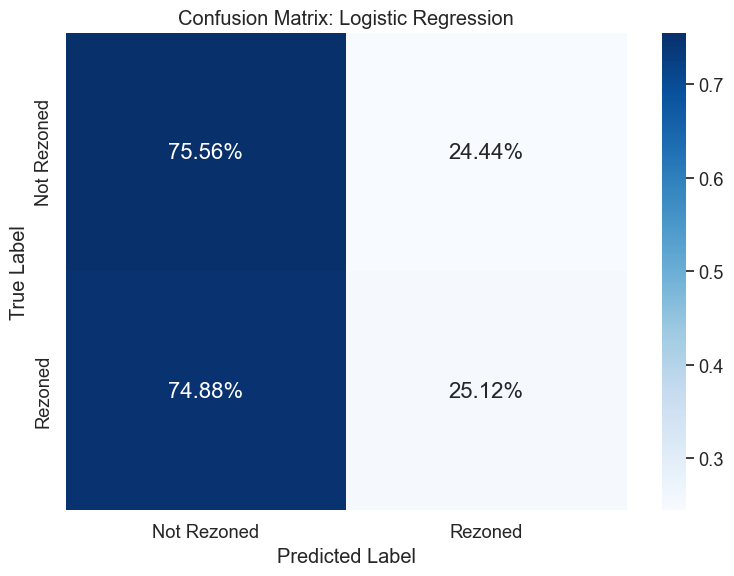


RANDOM FOREST - MODEL EVALUATION

Confusion Matrix:
[[36536  1779]
 [  751    49]]

Accuracy : 0.9353
Precision: 0.0268
Recall   : 0.0612
F1 Score : 0.0373
ROC AUC  : 0.9853


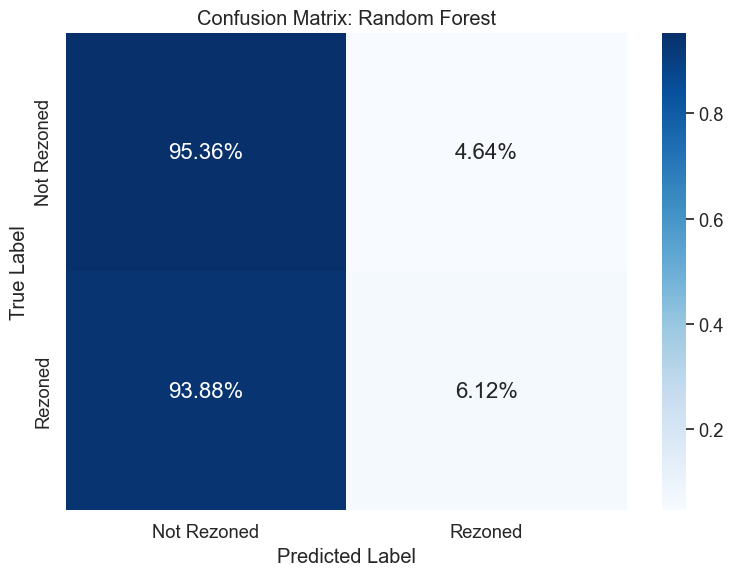


XGBOOST - MODEL EVALUATION

Confusion Matrix:
[[36386  1929]
 [  747    53]]

Accuracy : 0.9316
Precision: 0.0267
Recall   : 0.0663
F1 Score : 0.0381
ROC AUC  : 0.9850


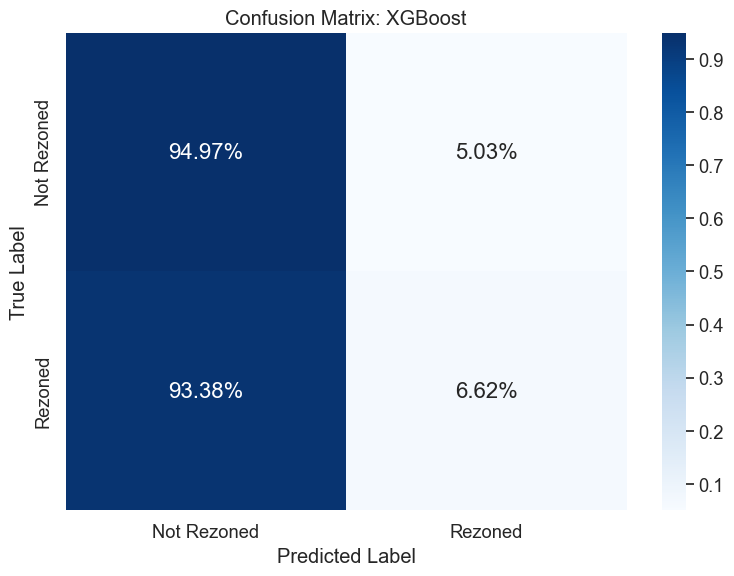


ADABOOST - MODEL EVALUATION

Confusion Matrix:
[[16407 21908]
 [  341   459]]

Accuracy : 0.4312
Precision: 0.0205
Recall   : 0.5737
F1 Score : 0.0396
ROC AUC  : 0.7738


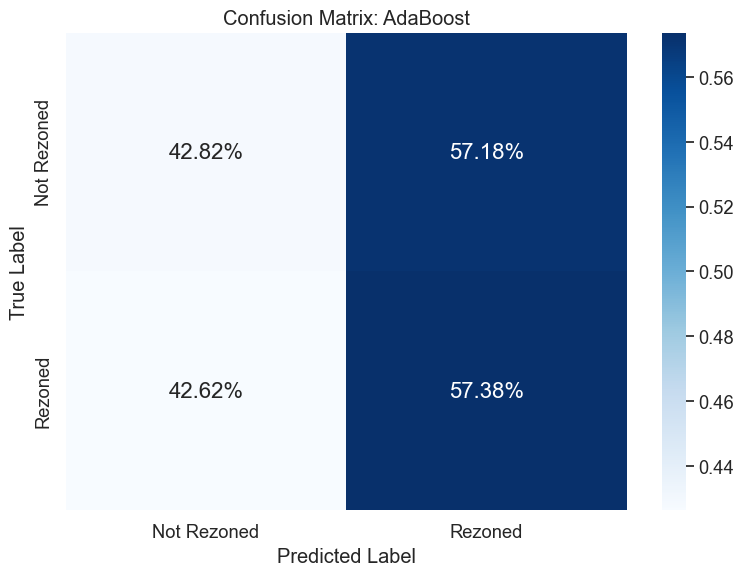


ENSEMBLE - MODEL EVALUATION

Confusion Matrix:
[[36098  2217]
 [  747    53]]

Accuracy : 0.9242
Precision: 0.0233
Recall   : 0.0663
F1 Score : 0.0345
ROC AUC  : 0.9796


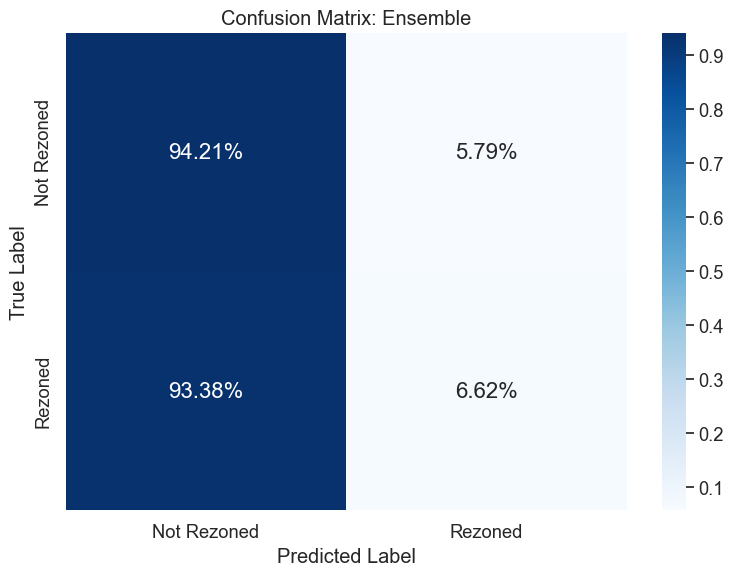


MODEL COMPARISON SUMMARY

                     accuracy  precision  recall      f1     auc
Logistic Regression    0.7452     0.0210  0.2512  0.0388  0.8696
Random Forest          0.9353     0.0268  0.0612  0.0373  0.9853
XGBoost                0.9316     0.0267  0.0662  0.0381  0.9850
AdaBoost               0.4312     0.0205  0.5738  0.0396  0.7738
Ensemble               0.9242     0.0233  0.0662  0.0345  0.9796

🏆 Best Accuracy : Random Forest (0.9353)
🏆 Best Precision: Random Forest (0.0268)
🏆 Best Recall   : AdaBoost (0.5738)
🏆 Best F1 Score : AdaBoost (0.0396)
🏆 Best ROC AUC  : Random Forest (0.9853)


In [97]:
# =============================================================
# Define evaluation function
# =============================================================

def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    Evaluate a classifier and display metrics + confusion matrix
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    y_pred_proba : array-like
        Predicted probabilities for positive class
    model_name : str
        Name of the model for display
    """
    print(f"\n{'='*60}")
    print(f"{model_name.upper()} - MODEL EVALUATION")
    print(f"{'='*60}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")
    
    # Normalized Confusion Matrix Heatmap
    cf_matrix = confusion_matrix(y_true, y_pred, normalize="true")
    df_cm = pd.DataFrame(cf_matrix, 
                        index=["Not Rezoned", "Rezoned"],
                        columns=["Not Rezoned", "Rezoned"])
    
    plt.figure(figsize=(8, 6))
    sns.set(font_scale=1.2)
    sns.heatmap(df_cm, 
                annot=True,
                annot_kws={"size": 16},
                fmt='.2%',
                cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc
    }


# =============================================================
# Evaluate All Models
# =============================================================

# Dictionary to store all results
results = {}

# Logistic Regression
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
results['Logistic Regression'] = evaluate_model(
    y_test, lr_pred, lr_pred_proba, "Logistic Regression"
)

# Random Forest
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
results['Random Forest'] = evaluate_model(
    y_test, rf_pred, rf_pred_proba, "Random Forest"
)

# XGBoost
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
results['XGBoost'] = evaluate_model(
    y_test, xgb_pred, xgb_pred_proba, "XGBoost"
)

# AdaBoost
ada_pred_proba = ada_model.predict_proba(X_test_scaled)[:, 1]
results['AdaBoost'] = evaluate_model(
    y_test, ada_pred, ada_pred_proba, "AdaBoost"
)

# Ensemble
ensemble_pred_proba = ensemble_model.predict_proba(X_test_scaled)[:, 1]
results['Ensemble'] = evaluate_model(
    y_test, ensemble_pred, ensemble_pred_proba, "Ensemble"
)

# =============================================================
# Summary Comparison Table
# =============================================================
print(f"\n{'='*60}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*60}\n")

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print(results_df.to_string())

# Highlight best performers
print(f"\n🏆 Best Accuracy : {results_df['accuracy'].idxmax()} ({results_df['accuracy'].max():.4f})")
print(f"🏆 Best Precision: {results_df['precision'].idxmax()} ({results_df['precision'].max():.4f})")
print(f"🏆 Best Recall   : {results_df['recall'].idxmax()} ({results_df['recall'].max():.4f})")
print(f"🏆 Best F1 Score : {results_df['f1'].idxmax()} ({results_df['f1'].max():.4f})")
print(f"🏆 Best ROC AUC  : {results_df['auc'].idxmax()} ({results_df['auc'].max():.4f})")

## Find the optimal threshold

Simply defining the threshold at 0.5 is too high and resulting in bad models. 

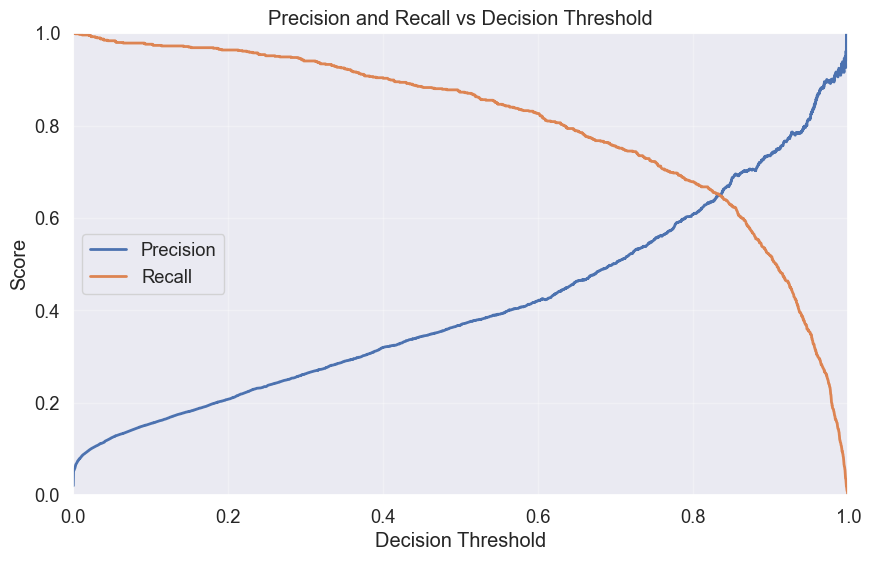


Threshold recommendations for different recall levels:

Target Recall: 50%
  Threshold: 0.9066
  Actual Recall: 50.00% (catch 400 of 800 rezoned parcels)
  Precision: 74.35%
  Parcels to review: 538 out of 39,115

Target Recall: 60%
  Threshold: 0.8630
  Actual Recall: 60.00% (catch 480 of 800 rezoned parcels)
  Precision: 69.87%
  Parcels to review: 687 out of 39,115

Target Recall: 70%
  Threshold: 0.7700
  Actual Recall: 70.00% (catch 560 of 800 rezoned parcels)
  Precision: 57.26%
  Parcels to review: 978 out of 39,115

Target Recall: 80%
  Threshold: 0.6330
  Actual Recall: 80.00% (catch 640 of 800 rezoned parcels)
  Precision: 44.51%
  Parcels to review: 1,438 out of 39,115

RANDOM FOREST - ADJUSTED THRESHOLD (0.15)

Confusion Matrix:
[[34816  3499]
 [   24   776]]

Accuracy : 0.9099
Precision: 0.1815
Recall   : 0.9700
F1 Score : 0.3058


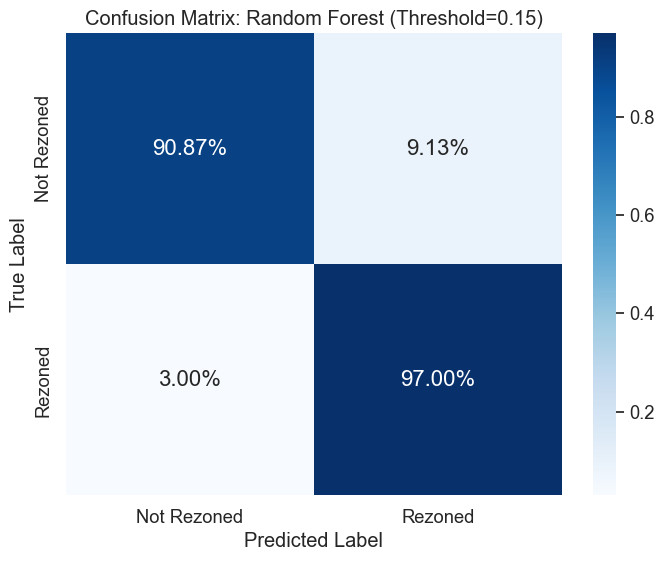

In [ ]:

# =============================================================
# Find Optimal Threshold
# =============================================================

# Get probability predictions
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate precision-recall curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, rf_pred_proba)

# Plot Precision-Recall vs Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precisions[:-1], label='Precision', linewidth=2)
plt.plot(thresholds_pr, recalls[:-1], label='Recall', linewidth=2)
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Decision Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

# Find threshold for different recall targets
target_recalls = [0.5, 0.6, 0.7, 0.8]
print("\nThreshold recommendations for different recall levels:")
print("="*60)
for target_recall in target_recalls:
    # Find threshold that gives closest to target recall
    idx = np.argmin(np.abs(recalls[:-1] - target_recall))
    threshold = thresholds_pr[idx]
    precision = precisions[idx]
    recall = recalls[idx]
    
    # Calculate how many parcels you'd need to review
    n_predicted_positive = (rf_pred_proba >= threshold).sum()
    
    print(f"\nTarget Recall: {target_recall*100:.0f}%")
    print(f"  Threshold: {threshold:.4f}")
    print(f"  Actual Recall: {recall:.2%} (catch {int(recall * 800)} of 800 rezoned parcels)")
    print(f"  Precision: {precision:.2%}")
    print(f"  Parcels to review: {n_predicted_positive:,} out of {len(y_test):,}")

# =============================================================
# Apply Custom Threshold
# =============================================================

# Choose your threshold (e.g., 0.15 for ~70% recall)
optimal_threshold = 0.15

# Make new predictions
rf_pred_adjusted = (rf_pred_proba >= optimal_threshold).astype(int)

# Evaluate with new threshold
print(f"\n{'='*60}")
print(f"RANDOM FOREST - ADJUSTED THRESHOLD ({optimal_threshold})")
print(f"{'='*60}")

cm = confusion_matrix(y_test, rf_pred_adjusted)
print("\nConfusion Matrix:")
print(cm)

acc = accuracy_score(y_test, rf_pred_adjusted)
prec = precision_score(y_test, rf_pred_adjusted, zero_division=0)
rec = recall_score(y_test, rf_pred_adjusted)
f1 = f1_score(y_test, rf_pred_adjusted)

print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# Show confusion matrix
cf_matrix = confusion_matrix(y_test, rf_pred_adjusted, normalize="true")
df_cm = pd.DataFrame(cf_matrix, 
                     index=["Not Rezoned", "Rezoned"],
                     columns=["Not Rezoned", "Rezoned"])

plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, annot_kws={"size": 16}, fmt='.2%', cmap='Blues')
plt.title(f"Confusion Matrix: Random Forest (Threshold={optimal_threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Re-define the optimal threshold 

Redefine at 0.15. 

## Re-define the optimal threshold 

Redefine at 0.15. 


LOGISTIC REGRESSION - MODEL EVALUATION (Threshold=0.3)

Confusion Matrix:
[[24099 14216]
 [   38   762]]

Accuracy : 0.6356
Precision: 0.0509
Recall   : 0.9525
F1 Score : 0.0966
ROC AUC  : 0.8696

Parcels flagged for review: 14,978 out of 39,115 (38.3%)


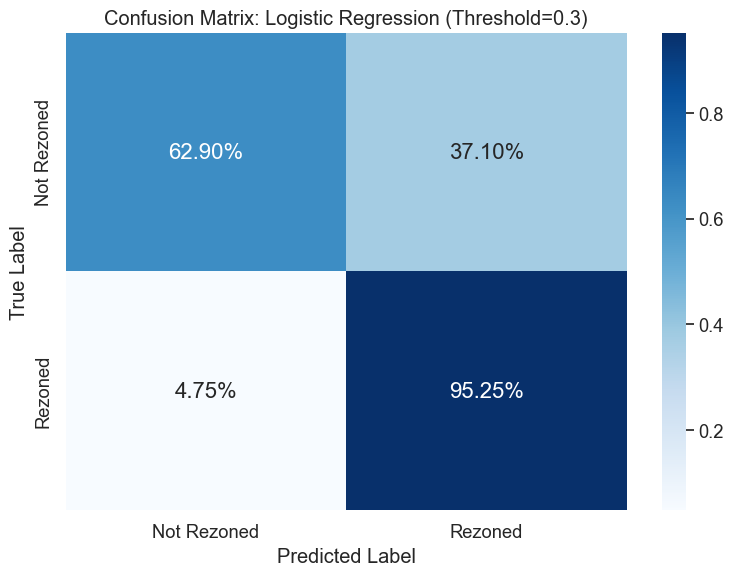


RANDOM FOREST - MODEL EVALUATION (Threshold=0.3)

Confusion Matrix:
[[36210  2105]
 [   48   752]]

Accuracy : 0.9450
Precision: 0.2632
Recall   : 0.9400
F1 Score : 0.4113
ROC AUC  : 0.9853

Parcels flagged for review: 2,857 out of 39,115 (7.3%)


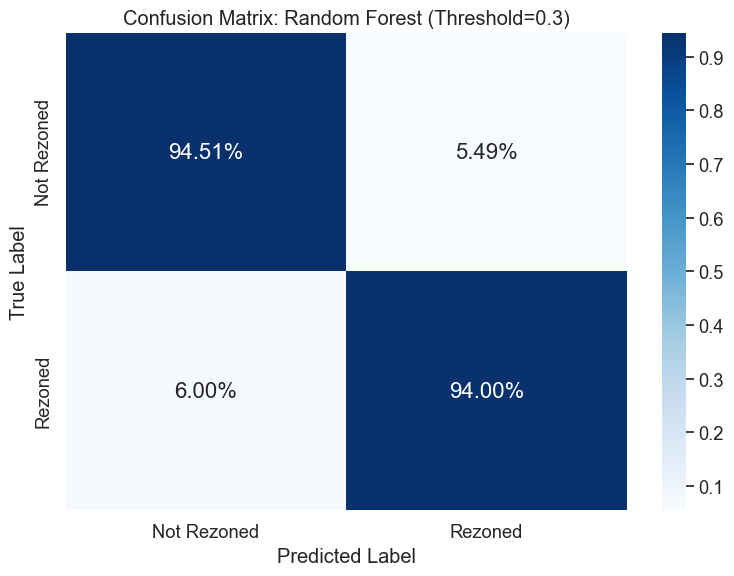


XGBOOST - MODEL EVALUATION (Threshold=0.3)

Confusion Matrix:
[[36369  1946]
 [   61   739]]

Accuracy : 0.9487
Precision: 0.2752
Recall   : 0.9237
F1 Score : 0.4241
ROC AUC  : 0.9850

Parcels flagged for review: 2,685 out of 39,115 (6.9%)


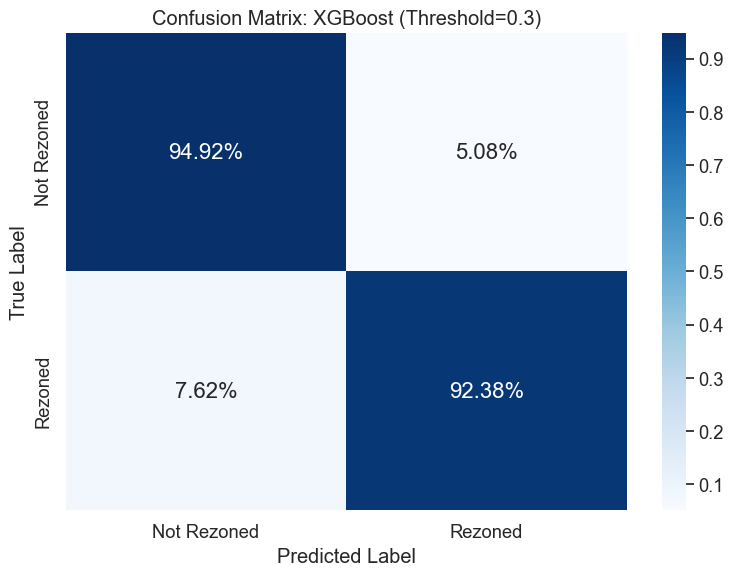


ADABOOST - MODEL EVALUATION (Threshold=0.3)

Confusion Matrix:
[[13100 25215]
 [    0   800]]

Accuracy : 0.3554
Precision: 0.0308
Recall   : 1.0000
F1 Score : 0.0597
ROC AUC  : 0.7738

Parcels flagged for review: 26,015 out of 39,115 (66.5%)


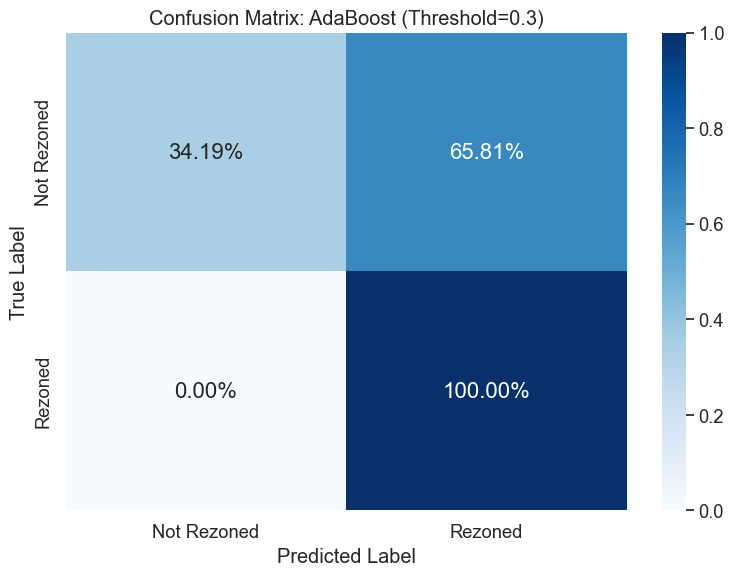


ENSEMBLE - MODEL EVALUATION (Threshold=0.3)

Confusion Matrix:
[[32815  5500]
 [   24   776]]

Accuracy : 0.8588
Precision: 0.1236
Recall   : 0.9700
F1 Score : 0.2193
ROC AUC  : 0.9796

Parcels flagged for review: 6,276 out of 39,115 (16.0%)


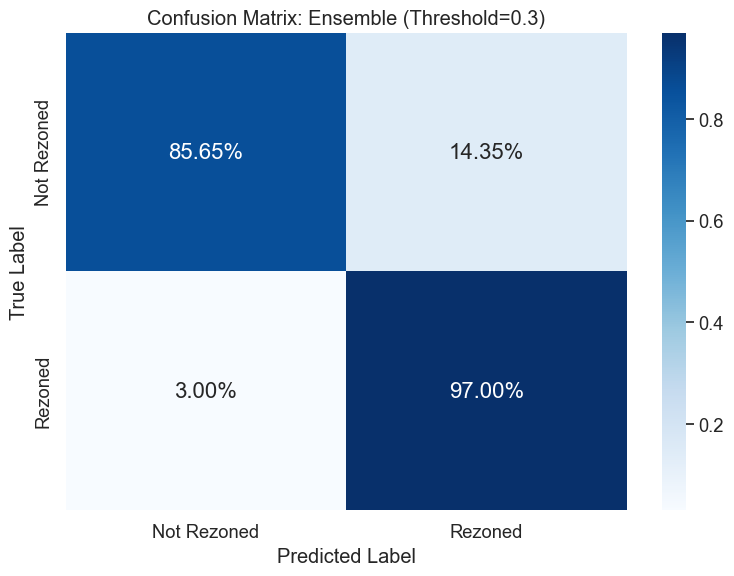


MODEL COMPARISON SUMMARY (Threshold=0.3)

                     accuracy  precision  recall      f1     auc  n_flagged
Logistic Regression    0.6356     0.0509  0.9525  0.0966  0.8696    14978.0
Random Forest          0.9450     0.2632  0.9400  0.4113  0.9853     2857.0
XGBoost                0.9487     0.2752  0.9238  0.4241  0.9850     2685.0
AdaBoost               0.3554     0.0308  1.0000  0.0597  0.7738    26015.0
Ensemble               0.8588     0.1236  0.9700  0.2193  0.9796     6276.0

🏆 Best Accuracy : XGBoost (0.9487)
🏆 Best Precision: XGBoost (0.2752)
🏆 Best Recall   : AdaBoost (1.0000)
🏆 Best F1 Score : XGBoost (0.4241)
🏆 Best ROC AUC  : Random Forest (0.9853)

📊 Parcels Flagged for Review:
  Logistic Regression: 14,978
  Random Forest: 2,857
  XGBoost: 2,685
  AdaBoost: 26,015
  Ensemble: 6,276


In [114]:
# =============================================================
# Define evaluation function with custom threshold
# =============================================================
def evaluate_model(y_true, y_pred_proba, model_name, threshold=0.15):
    """
    Evaluate a classifier and display metrics + confusion matrix
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred_proba : array-like
        Predicted probabilities for positive class
    model_name : str
        Name of the model for display
    threshold : float
        Decision threshold (default 0.15)
    """
    # Apply custom threshold to get predictions
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    print(f"\n{'='*60}")
    print(f"{model_name.upper()} - MODEL EVALUATION (Threshold={threshold})")
    print(f"{'='*60}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")
    
    # Show how many parcels would be flagged
    n_flagged = y_pred.sum()
    n_total = len(y_pred)
    print(f"\nParcels flagged for review: {n_flagged:,} out of {n_total:,} ({n_flagged/n_total*100:.1f}%)")
    
    # Normalized Confusion Matrix Heatmap
    cf_matrix = confusion_matrix(y_true, y_pred, normalize="true")
    df_cm = pd.DataFrame(cf_matrix, 
                        index=["Not Rezoned", "Rezoned"],
                        columns=["Not Rezoned", "Rezoned"])
    
    plt.figure(figsize=(8, 6))
    sns.set(font_scale=1.2)
    sns.heatmap(df_cm, 
                annot=True,
                annot_kws={"size": 16},
                fmt='.2%',
                cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name} (Threshold={threshold})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'n_flagged': n_flagged
    }

# =============================================================
# Evaluate All Models with 0.15 Threshold
# =============================================================

# Set your optimal threshold
#OPTIMAL_THRESHOLD = 0.15
OPTIMAL_THRESHOLD = 0.3
#OPTIMAL_THRESHOLD = 0.5

# Dictionary to store all results
results = {}

# Logistic Regression
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
results['Logistic Regression'] = evaluate_model(
    y_test, lr_pred_proba, "Logistic Regression", threshold=OPTIMAL_THRESHOLD
)

# Random Forest
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
results['Random Forest'] = evaluate_model(
    y_test, rf_pred_proba, "Random Forest", threshold=OPTIMAL_THRESHOLD
)

# XGBoost
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
results['XGBoost'] = evaluate_model(
    y_test, xgb_pred_proba, "XGBoost", threshold=OPTIMAL_THRESHOLD
)

# AdaBoost
ada_pred_proba = ada_model.predict_proba(X_test_scaled)[:, 1]
results['AdaBoost'] = evaluate_model(
    y_test, ada_pred_proba, "AdaBoost", threshold=OPTIMAL_THRESHOLD
)

# Ensemble
ensemble_pred_proba = ensemble_model.predict_proba(X_test_scaled)[:, 1]
results['Ensemble'] = evaluate_model(
    y_test, ensemble_pred_proba, "Ensemble", threshold=OPTIMAL_THRESHOLD
)

# =============================================================
# Summary Comparison Table
# =============================================================
print(f"\n{'='*60}")
print(f"MODEL COMPARISON SUMMARY (Threshold={OPTIMAL_THRESHOLD})")
print(f"{'='*60}\n")

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print(results_df.to_string())

# Highlight best performers
print(f"\n🏆 Best Accuracy : {results_df['accuracy'].idxmax()} ({results_df['accuracy'].max():.4f})")
print(f"🏆 Best Precision: {results_df['precision'].idxmax()} ({results_df['precision'].max():.4f})")
print(f"🏆 Best Recall   : {results_df['recall'].idxmax()} ({results_df['recall'].max():.4f})")
print(f"🏆 Best F1 Score : {results_df['f1'].idxmax()} ({results_df['f1'].max():.4f})")
print(f"🏆 Best ROC AUC  : {results_df['auc'].idxmax()} ({results_df['auc'].max():.4f})")

print(f"\n📊 Parcels Flagged for Review:")
for model_name, n_flagged in results_df['n_flagged'].items():
    print(f"  {model_name}: {int(n_flagged):,}")

In [115]:

# troubleshooting
count_table = y.value_counts()
print(count_table)
print("\nPercentages:")
print(count_table / count_table.sum())


urban_zone_flag
0    191572
1      4002
Name: count, dtype: int64

Percentages:
urban_zone_flag
0    0.979537
1    0.020463
Name: count, dtype: float64


In [116]:
# =============================================================
# Step 6: Feature Importance Plots
# =============================================================

print("Plotting feature importances...")

importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values().plot.barh(figsize=(10, 12))

plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rf_feature_importance.png", dpi=160)
plt.close()

Plotting feature importances...


In [117]:
importances

dist_to_station_miles    0.191328
parcel_area              0.177056
in_taz                   0.024101
public_transit_pct       0.022257
walked_pct               0.022030
drove_pct                0.029333
pct_renters              0.151515
vacancy_rate             0.040879
median_income            0.059390
median_rent              0.095537
pct_white                0.061810
pct_black                0.037773
pct_asian                0.039345
pct_latino               0.022667
pct_college_plus         0.024979
dtype: float64

In [ ]:
# =============================================================
# Step 7: Predict Suitability for All Parcels
# =============================================================

print("Predicting suitability probabilities...")
parcels_model["suitability_score"] = ensemble.predict_proba(
    scaler.transform(parcels_model[feature_cols].fillna(0))
)[:, 1]

# Identify parcels the model thinks *should* be urban but aren't
parcels_model["predicted_urban_flag"] = (parcels_model["suitability_score"] > 0.5).astype(int)

# Find rezoning opportunities (model says urban, but currently not)
parcels_model["potential_rezoning_candidate"] = np.where(
    (parcels_model["predicted_urban_flag"] == 1) &
    (parcels_model["urban_zone_flag"] == 0),
    1, 0
)

# Save ALL parcels with scores
parcels_model.to_parquet(OUTPUT_DIR / "parcels_with_suitability.parquet")

# Save ONLY the rezoning candidates
print("Saving GeoJSON of potentially mis-zoned parcels...")
rezoning_candidates = parcels_model[parcels_model["potential_rezoning_candidate"] == 1]
rezoning_candidates.to_file(OUTPUT_DIR / "rezoning_opportunities.geojson", driver="GeoJSON")

print(f"\nFound {len(rezoning_candidates)} potential rezoning candidates")
print(f"({len(rezoning_candidates)/len(parcels_model)*100:.1f}% of all parcels)")

Predicting suitability probabilities...


/opt/anaconda3/envs/datasci/lib/python3.14/site-packages/geopandas/io/_geoarrow.py:133: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_attr[col] = None


Saving GeoJSON of potentially mis-zoned parcels...

Found 5846 potential rezoning candidates
(3.0% of all parcels)


In [118]:
# Use 0.15 threshold for final predictions on all parcels
optimal_threshold = 0.3

# Predict on ALL parcels
parcels_model["suitability_score"] = rf_model.predict_proba(
    scaler.transform(parcels_model[feature_cols].fillna(0))
)[:, 1]

# Use adjusted threshold instead of 0.5
parcels_model["predicted_urban_flag"] = (
    parcels_model["suitability_score"] > optimal_threshold
).astype(int)

# Find rezoning candidates (same logic as before)
parcels_model["potential_rezoning_candidate"] = np.where(
    (parcels_model["predicted_urban_flag"] == 1) &
    (parcels_model["urban_zone_flag"] == 0),
    1, 0
)

# Save results
print(f"\nFound {parcels_model['potential_rezoning_candidate'].sum():,} potential rezoning candidates")
parcels_model.to_parquet(OUTPUT_DIR / "parcels_with_suitability.parquet")

# Save only the candidates
rezoning_candidates = parcels_model[parcels_model["potential_rezoning_candidate"] == 1]
rezoning_candidates.to_file(OUTPUT_DIR / "rezoning_opportunities.geojson", driver="GeoJSON")


Found 10,117 potential rezoning candidates


/opt/anaconda3/envs/datasci/lib/python3.14/site-packages/geopandas/io/_geoarrow.py:133: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_attr[col] = None


In [ ]:
rezoning_candidates

(10117, 55)

In [120]:
parcels_model["potential_rezoning_candidate"].sum()

np.int64(10117)

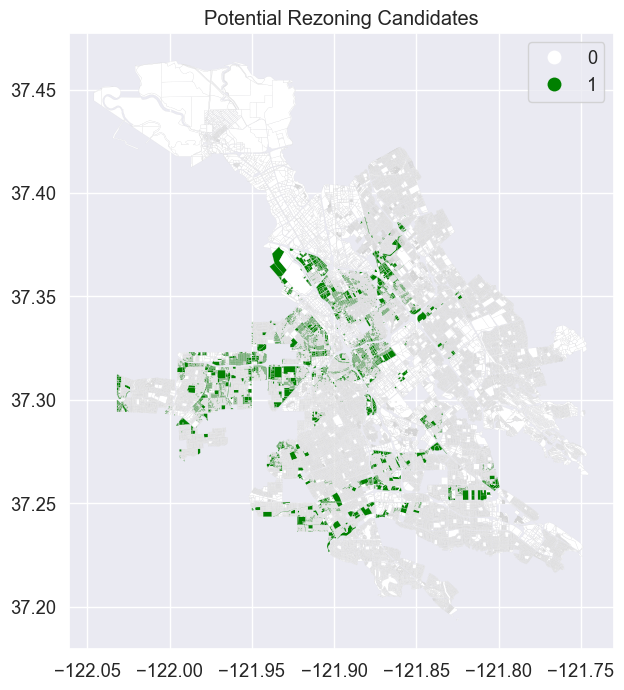

In [122]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(10, 8))

# Define colors: 0=gray, 1=green
colors = ['white', 'green']
cmap = ListedColormap(colors)

parcels_model.plot(column="potential_rezoning_candidate", 
                   cmap=cmap,
                   categorical=True,
                   legend=True,
                   ax=ax,
                   edgecolor='lightgrey',
                   linewidth=0.1)
plt.title("Potential Rezoning Candidates")
plt.show()